In [1]:
# ===========================================
# STEP 1: Import Required Libraries
# ===========================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

print("=" * 50)
print("All libraries imported successfully!")
print("=" * 50)

All libraries imported successfully!


# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

### Author:
GADADESI HARSHITH

### Objective

The objective of this project is to develop an end-to-end sales forecasting and demand intelligence system using historical retail sales data. The project includes exploratory data analysis, time series forecasting using multiple models, anomaly detection, product demand segmentation, and deployment of an interactive dashboard using Streamlit to support business decision-making.

# Task 1: Data Loading, Merging & Deep Exploration

In this section, we load the datasets, inspect their structure, extract time-based features, identify data quality issues, and perform an in-depth exploratory data analysis to understand sales patterns across products, regions, and time.

In [2]:
# ==========================================================
# Load Superstore Sales Dataset and Video Game Sales Dataset
# ==========================================================

sales_df = pd.read_csv("data/train.csv")
vg_df = pd.read_csv("data/vgsales.csv")

print("=" * 60)
print("Superstore Sales Dataset Loaded Successfully")
print("=" * 60)
print(f"Rows    : {sales_df.shape[0]}")
print(f"Columns : {sales_df.shape[1]}")

print("\n")

print("=" * 60)
print("Video Game Sales Dataset Loaded Successfully")
print("=" * 60)
print(f"Rows    : {vg_df.shape[0]}")
print(f"Columns : {vg_df.shape[1]}")

Superstore Sales Dataset Loaded Successfully
Rows    : 9800
Columns : 18


Video Game Sales Dataset Loaded Successfully
Rows    : 16598
Columns : 11


In [3]:
# ==========================================================
# Display First Five Rows
# ==========================================================

print("Superstore Sales Dataset")
display(sales_df.head())

print("\nVideo Game Sales Dataset")
display(vg_df.head())

Superstore Sales Dataset


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



Video Game Sales Dataset


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("Superstore Dataset Information")
print("=" * 60)

sales_df.info()

print("\n")

print("=" * 60)
print("Video Game Dataset Information")
print("=" * 60)

vg_df.info()

Superstore Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 n

In [5]:
# ==========================================================
# Statistical Summary
# ==========================================================

display(sales_df.describe(include="all"))

display(vg_df.describe(include="all"))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


In [6]:
# ==========================================================
# Missing Values
# ==========================================================

missing_sales = sales_df.isnull().sum().sort_values(ascending=False)

missing_vg = vg_df.isnull().sum().sort_values(ascending=False)

print("Missing Values in Sales Dataset")
display(missing_sales[missing_sales > 0])

print("\nMissing Values in Video Game Dataset")
display(missing_vg[missing_vg > 0])

Missing Values in Sales Dataset


Postal Code    11
dtype: int64


Missing Values in Video Game Dataset


Year         271
Publisher     58
dtype: int64

In [7]:
# ==========================================================
# Duplicate Records
# ==========================================================

print(f"Duplicate Rows in Sales Dataset : {sales_df.duplicated().sum()}")

print(f"Duplicate Rows in Video Game Dataset : {vg_df.duplicated().sum()}")

Duplicate Rows in Sales Dataset : 0
Duplicate Rows in Video Game Dataset : 0


In [8]:
# ==========================================================
# Data Types
# ==========================================================

display(sales_df.dtypes)

display(vg_df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

## Date Parsing and Time Feature Engineering

Time-based features play a crucial role in forecasting problems. In this section, the date columns are converted into datetime format, additional calendar-based features are extracted, and shipping duration is calculated for further business analysis.

In [9]:
# ==========================================================
# Convert Date Columns into Datetime Format
# ==========================================================

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

print("Date conversion completed successfully.\n")

print(sales_df[["Order Date", "Ship Date"]].dtypes)

Date conversion completed successfully.

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [10]:
# ==========================================================
# Extract Time Features
# ==========================================================

sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week.astype(int)

sales_df["Day"] = sales_df["Order Date"].dt.day

sales_df["Day Name"] = sales_df["Order Date"].dt.day_name()

sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

print("Time Features Created Successfully.")

display(
    sales_df[
        [
            "Order Date",
            "Year",
            "Month",
            "Month Name",
            "Week Number",
            "Day",
            "Day Name",
            "Quarter"
        ]
    ].head()
)

Time Features Created Successfully.


,Order Date,Year,Month,Month Name,Week Number,Day,Day Name,Quarter
0,2017-11-08,2017,11,November,45,8,Wednesday,4
1,2017-11-08,2017,11,November,45,8,Wednesday,4
2,2017-06-12,2017,6,June,24,12,Monday,2
3,2016-10-11,2016,10,October,41,11,Tuesday,4
4,2016-10-11,2016,10,October,41,11,Tuesday,4


In [11]:
# ==========================================================
# Create Season Feature
# ==========================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


sales_df["Season"] = sales_df["Month"].apply(get_season)

display(
    sales_df[
        [
            "Month",
            "Month Name",
            "Season"
        ]
    ].head(12)
)

,Month,Month Name,Season
0,11,November,Autumn
1,11,November,Autumn
2,6,June,Summer
3,10,October,Autumn
4,10,October,Autumn
5,6,June,Summer
6,6,June,Summer
7,6,June,Summer
8,6,June,Summer
9,6,June,Summer


In [12]:
# ==========================================================
# Shipping Duration
# ==========================================================

sales_df["Shipping Days"] = (
    sales_df["Ship Date"] -
    sales_df["Order Date"]
).dt.days

print("Shipping Duration Added Successfully.")

display(
    sales_df[
        [
            "Order Date",
            "Ship Date",
            "Shipping Days"
        ]
    ].head()
)

Shipping Duration Added Successfully.


,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [13]:
# ==========================================================
# Verify New Dataset
# ==========================================================

print("Dataset Shape")

print(sales_df.shape)

print("\n")

display(sales_df.head())

Dataset Shape
(9800, 27)




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Year,Month,Month Name,Week Number,Day,Day Name,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,November,45,8,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,November,45,8,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,June,24,12,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,October,41,11,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,October,41,11,Tuesday,4,Autumn,7


# Deep Exploratory Data Analysis (EDA)

This section explores historical sales trends, regional performance, product categories, seasonal patterns, and customer purchasing behaviour to understand the factors influencing demand before forecasting.

# Deep Exploratory Data Analysis (EDA)

The purpose of this exploratory analysis is to understand historical sales behaviour, identify high-performing categories and regions, examine seasonal trends, and uncover patterns that will support accurate demand forecasting.

In [14]:
# ==========================================================
# Visualization Settings
# ==========================================================

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

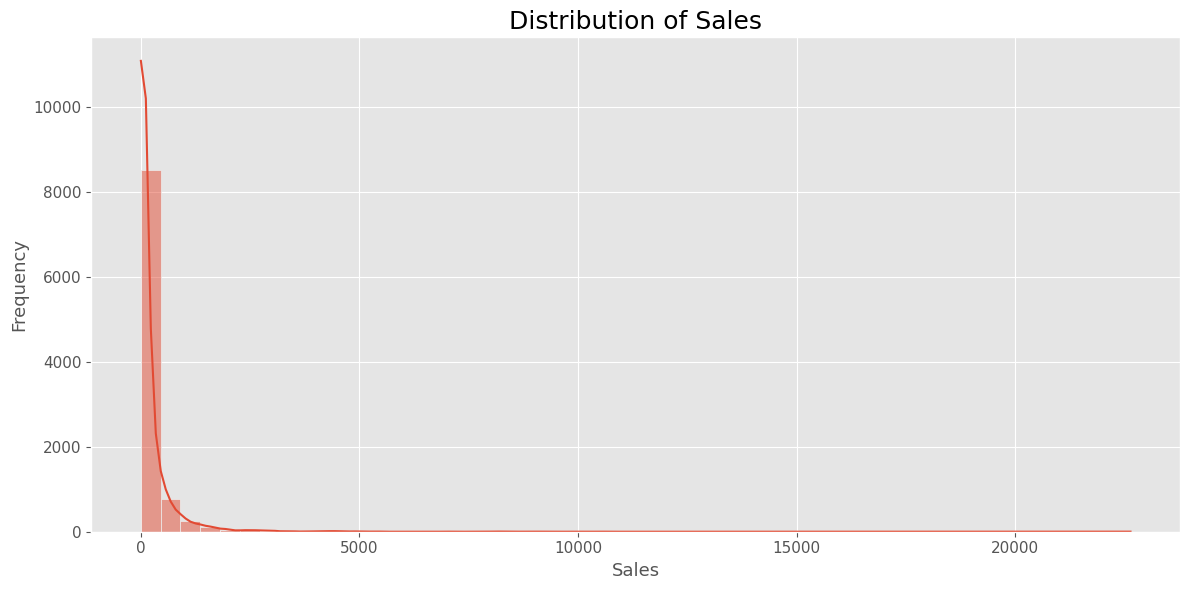

In [15]:
# ==========================================================
# Distribution of Sales
# ==========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    sales_df["Sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "charts/sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

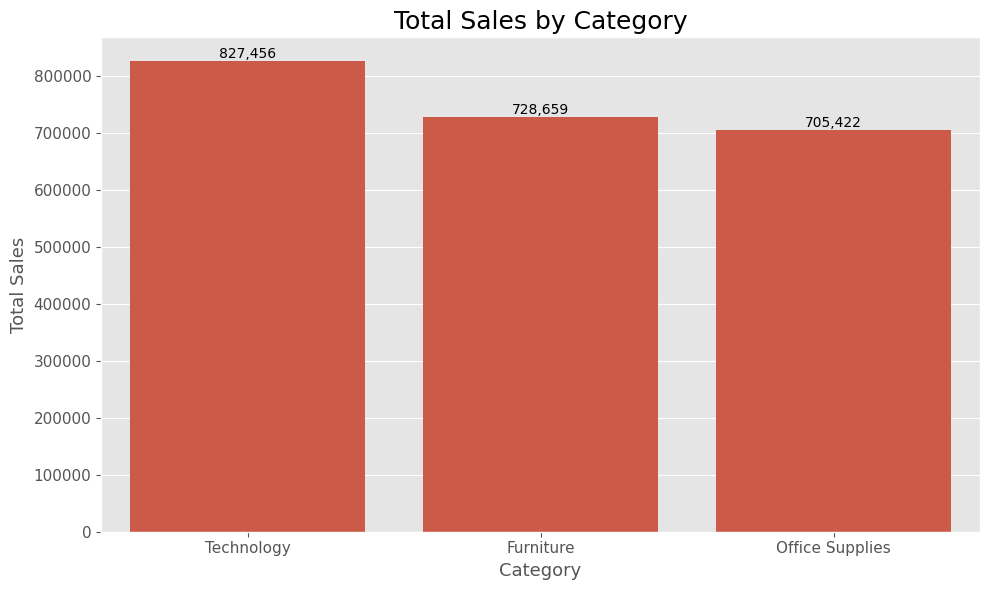

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [16]:
# ==========================================================
# Total Sales by Category
# ==========================================================

category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

for i, value in enumerate(category_sales.values):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "charts/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(category_sales)

### Business Insight

- Technology generates the highest overall revenue among all product categories.
- Furniture contributes the second-highest sales, followed by Office Supplies.
- This suggests that inventory planning should prioritize Technology products during demand forecasting.

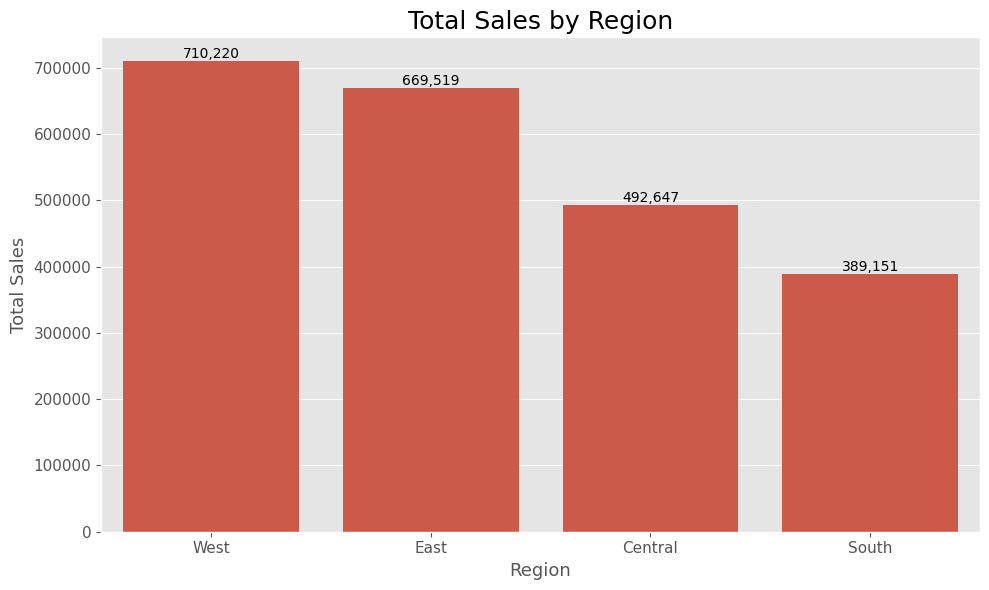

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [17]:
# ==========================================================
# Total Sales by Region
# ==========================================================

region_sales = (
    sales_df
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

for i, value in enumerate(region_sales.values):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "charts/region_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(region_sales)

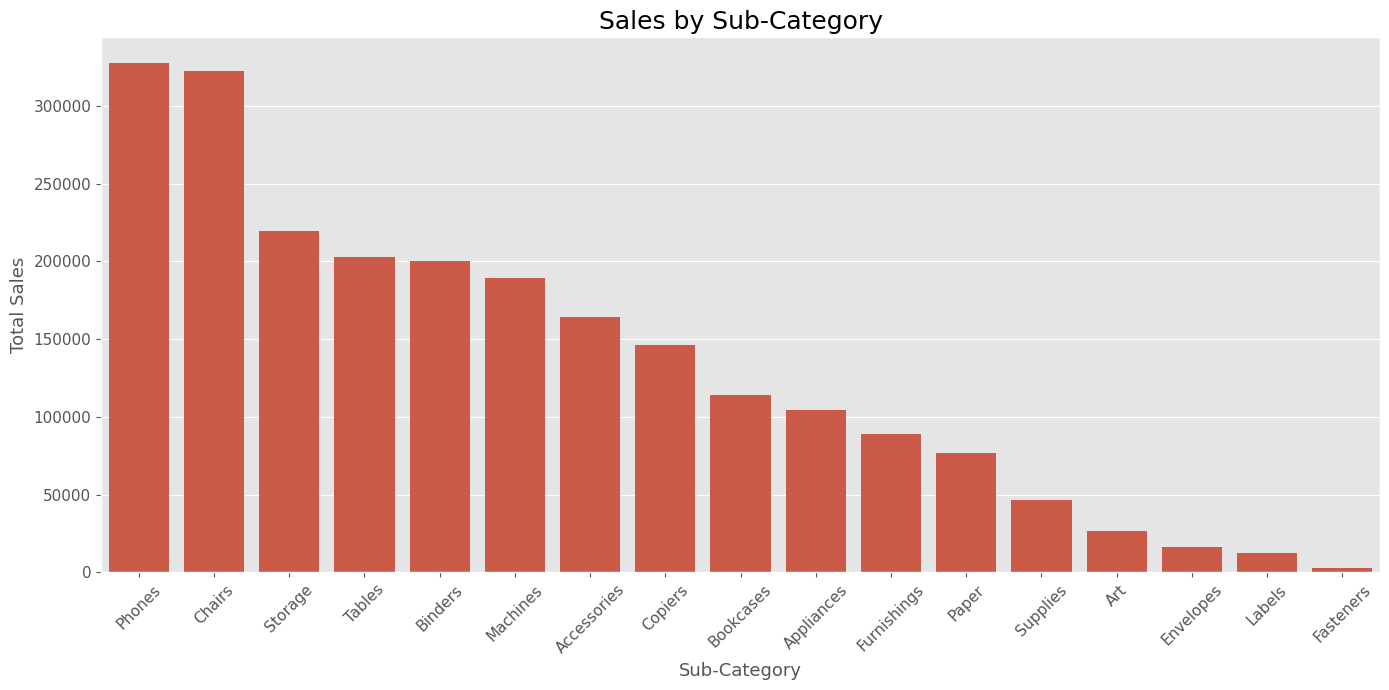

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [18]:
# ==========================================================
# Sales by Sub-Category
# ==========================================================

subcategory_sales = (
    sales_df
    .groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    x=subcategory_sales.index,
    y=subcategory_sales.values
)

plt.xticks(rotation=45)

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "charts/subcategory_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(subcategory_sales)

## Business Question 1: Which Product Category Generates the Highest Total Revenue?

In [19]:
# ==========================================================
# Business Question 1
# Highest Revenue Generating Category
# ==========================================================

highest_category = category_sales.idxmax()
highest_sales = category_sales.max()

print("=" * 60)
print("Highest Revenue Generating Category")
print("=" * 60)

print(f"Category : {highest_category}")
print(f"Total Sales : ${highest_sales:,.2f}")

Highest Revenue Generating Category
Category : Technology
Total Sales : $827,455.87


### Observation

Technology is the highest revenue-generating product category with total sales exceeding all other categories. This indicates strong customer demand and suggests that maintaining optimal inventory levels for Technology products is essential for maximizing future revenue.

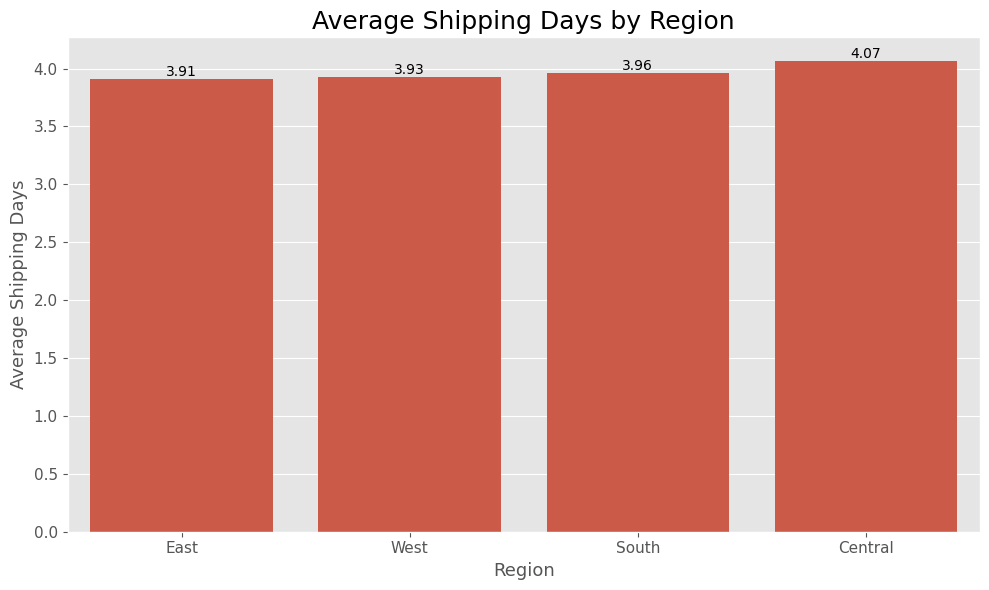

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

In [20]:
# ==========================================================
# Average Shipping Time by Region
# ==========================================================

shipping_region = (
    sales_df
    .groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

for i, value in enumerate(shipping_region.values):
    ax.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "charts/shipping_days_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(shipping_region)

### Observation

The average shipping duration is relatively consistent across all regions, indicating a well-balanced logistics network. Minor regional differences may reflect transportation distances or warehouse locations.

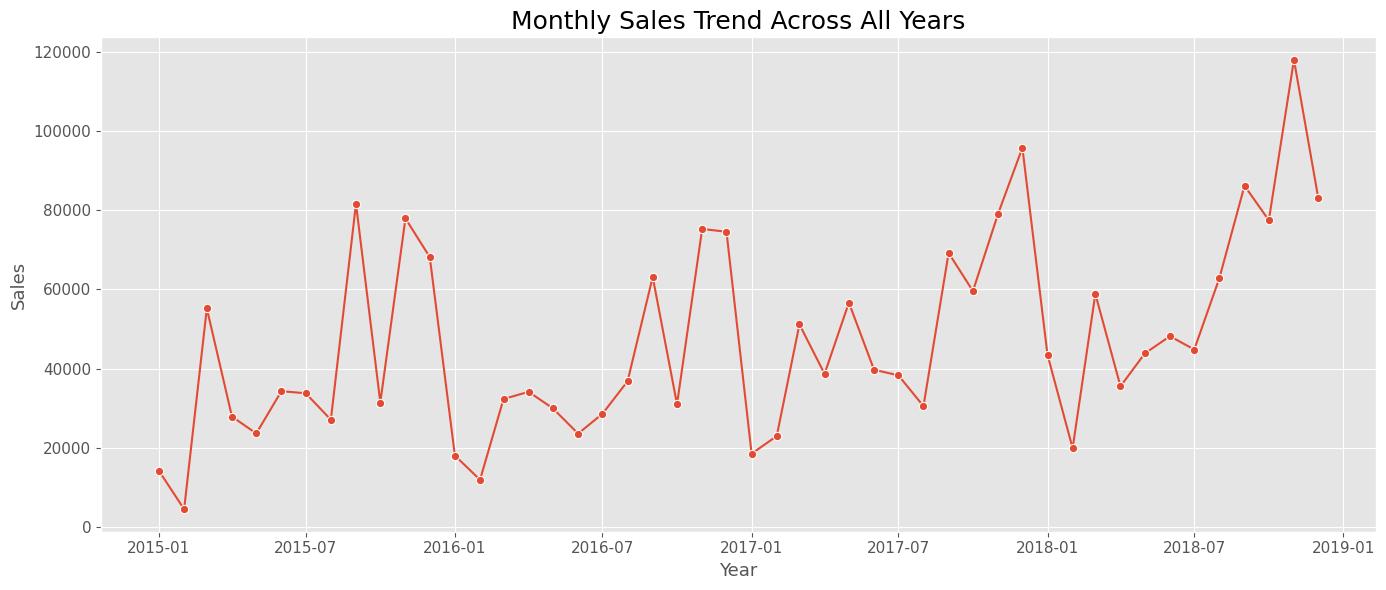

In [21]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

monthly_sales = (
    sales_df
    .groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x="Date",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend Across All Years")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The monthly sales trend highlights recurring fluctuations over time, suggesting the presence of seasonality. These recurring patterns justify the use of time-series forecasting models such as SARIMA and Prophet in later stages of the project.

# Time Series Data Preparation

Before building forecasting models, the sales data is aggregated into weekly and monthly time series. These aggregated datasets provide the appropriate granularity required for decomposition, forecasting, anomaly detection, and model comparison.

In [22]:
# ==========================================================
# Weekly Sales Aggregation
# ==========================================================

weekly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

print("Weekly Dataset Shape")
print(weekly_sales.shape)

display(weekly_sales.head())

Weekly Dataset Shape
(209, 2)


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [23]:
# ==========================================================
# Monthly Sales Aggregation
# ==========================================================

monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

print("Monthly Dataset Shape")
print(monthly_sales.shape)

display(monthly_sales.head())

Monthly Dataset Shape
(48, 2)


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [24]:
# ==========================================================
# Save Aggregated Time Series
# ==========================================================

weekly_sales.to_csv(
    "data/weekly_sales.csv",
    index=False
)

monthly_sales.to_csv(
    "data/monthly_sales.csv",
    index=False
)

print("Weekly and Monthly datasets saved successfully.")

Weekly and Monthly datasets saved successfully.


In [67]:
# ==========================================================
# Daily Sales Aggregation
# ==========================================================

daily_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

print("Daily Sales Shape:", daily_sales.shape)

display(daily_sales.head())

Daily Sales Shape: (1230, 2)


,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


# Task 2: Time Series Analysis and Decomposition

Time series decomposition separates historical sales into trend, seasonal, and residual components. This helps identify long-term growth, recurring seasonal behaviour, and irregular fluctuations before forecasting.

## Time Series Decomposition

Time series decomposition separates the sales data into three important components:

- **Trend:** Long-term increase or decrease in sales.
- **Seasonality:** Repeating sales patterns over fixed periods.
- **Residual:** Random fluctuations that cannot be explained by trend or seasonality.

Understanding these components helps in selecting an appropriate forecasting model.

In [25]:
# ==========================================================
# Prepare Monthly Time Series
# ==========================================================

monthly_ts = monthly_sales.copy()

monthly_ts.set_index("Order Date", inplace=True)

monthly_ts = monthly_ts.asfreq("ME")

display(monthly_ts.head())

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [26]:
# ==========================================================
# Seasonal Decomposition
# ==========================================================

decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

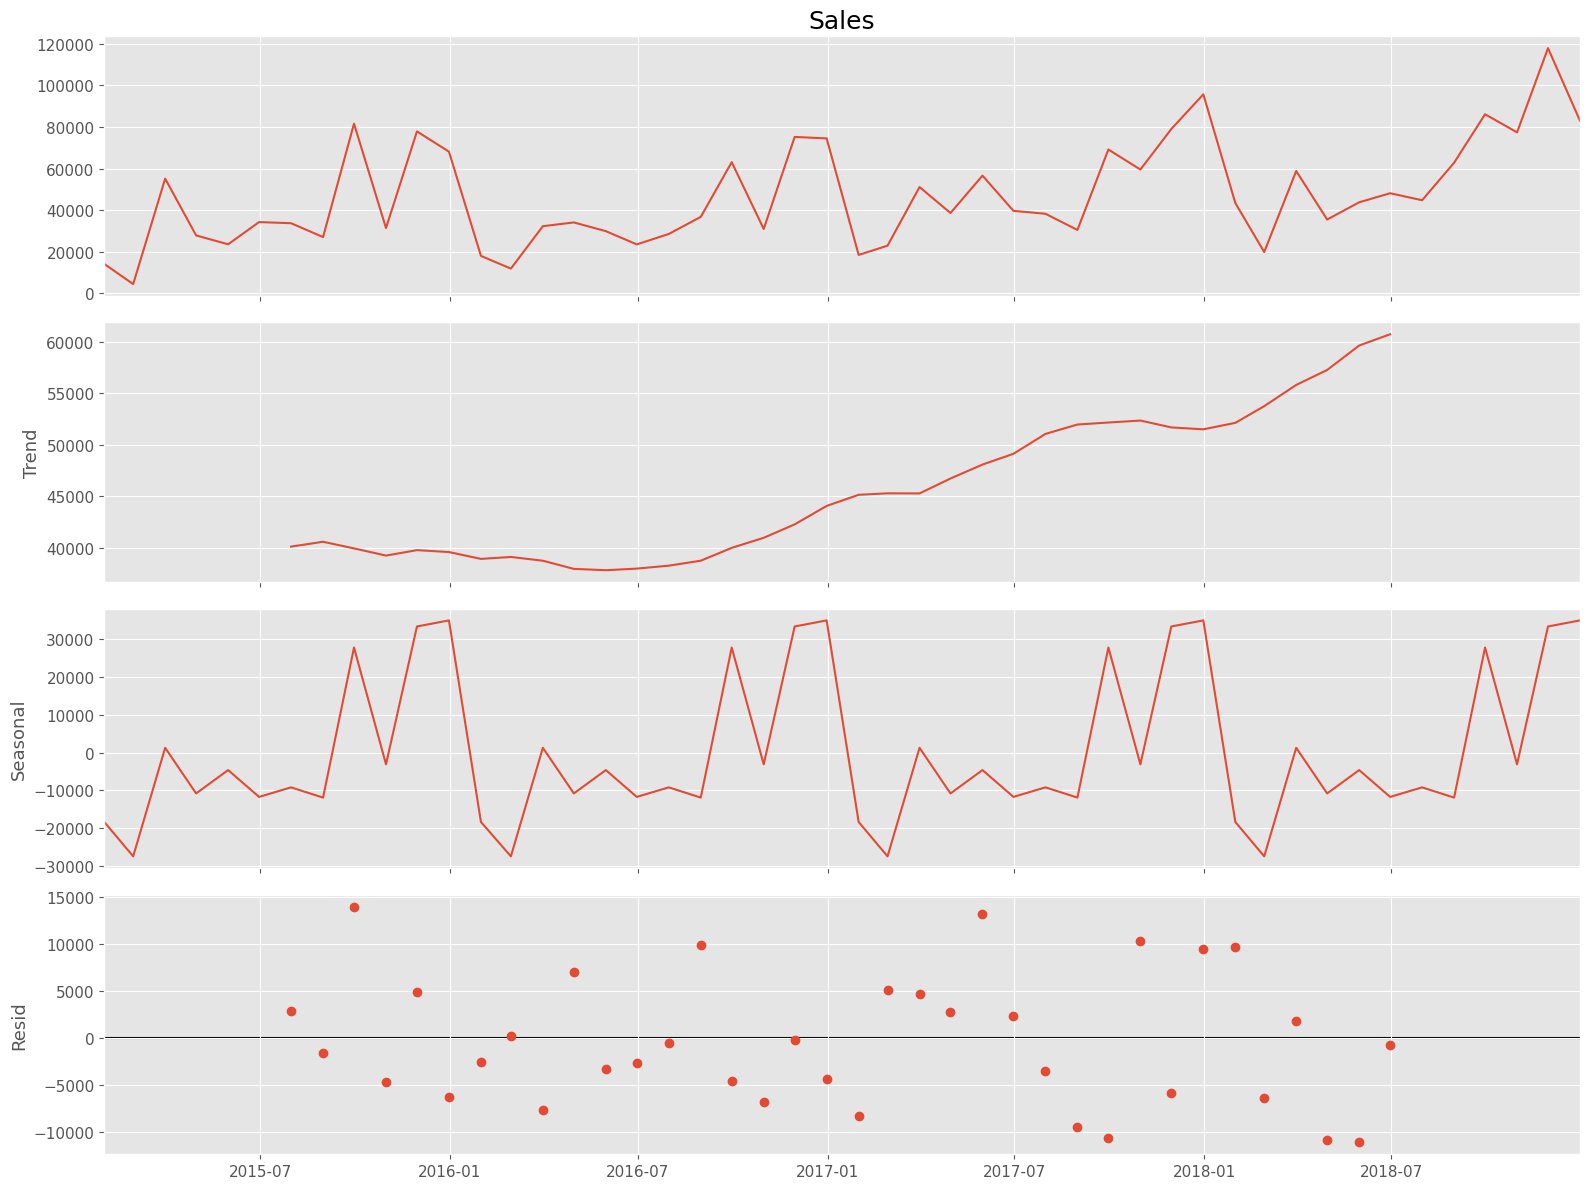

In [27]:
# ==========================================================
# Plot Time Series Decomposition
# ==========================================================

fig = decomposition.plot()

fig.set_size_inches(16, 12)

plt.tight_layout()

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

**Trend**

The trend component highlights the long-term movement in sales over the four-year period.

**Seasonality**

The seasonal component reveals recurring monthly patterns that indicate predictable fluctuations in customer demand.

**Residual**

The residual component represents irregular variations that cannot be explained by trend or seasonality and may indicate unusual business events or external factors.

In [28]:
# ==========================================================
# Augmented Dickey-Fuller Test
# ==========================================================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_ts["Sales"])

print("=" * 60)
print("Augmented Dickey-Fuller Test")
print("=" * 60)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

Augmented Dickey-Fuller Test
ADF Statistic : -4.4161
P-value       : 0.0003
Lags Used     : 0
Observations  : 47

Critical Values
1%: -3.5778
5%: -2.9253
10%: -2.6008


### What is Stationarity?

A time series is considered **stationary** if its statistical properties, such as mean and variance, remain relatively constant over time.

Most forecasting models, particularly SARIMA, perform better when the input time series is stationary. Therefore, the Augmented Dickey-Fuller (ADF) Test is used to determine whether differencing is required before model training.

### Interpretation of the ADF Test

The Augmented Dickey-Fuller (ADF) Test produced a p-value of **0.0003**, which is significantly lower than the commonly accepted threshold of **0.05**.

This indicates that the monthly sales time series is **stationary**, meaning its statistical properties remain relatively stable over time.

Since the data is already stationary, **additional differencing is not required** before training forecasting models such as SARIMA.

## Autocorrelation Analysis

Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots help identify temporal dependencies in the data and guide the selection of SARIMA parameters.

<Figure size 1400x600 with 0 Axes>

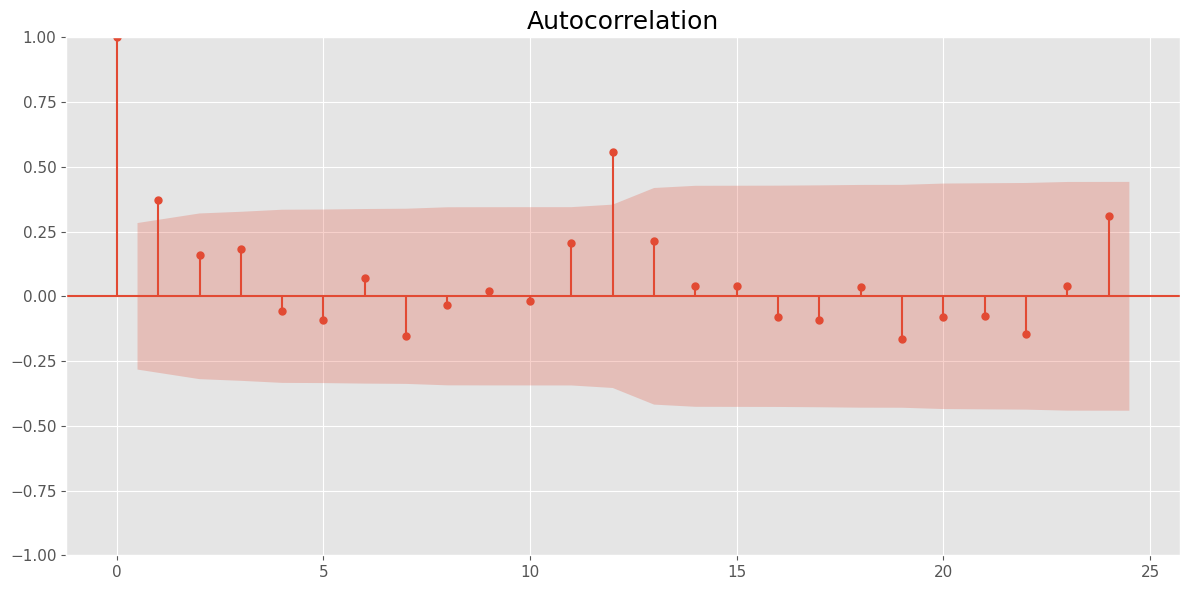

<Figure size 1400x600 with 0 Axes>

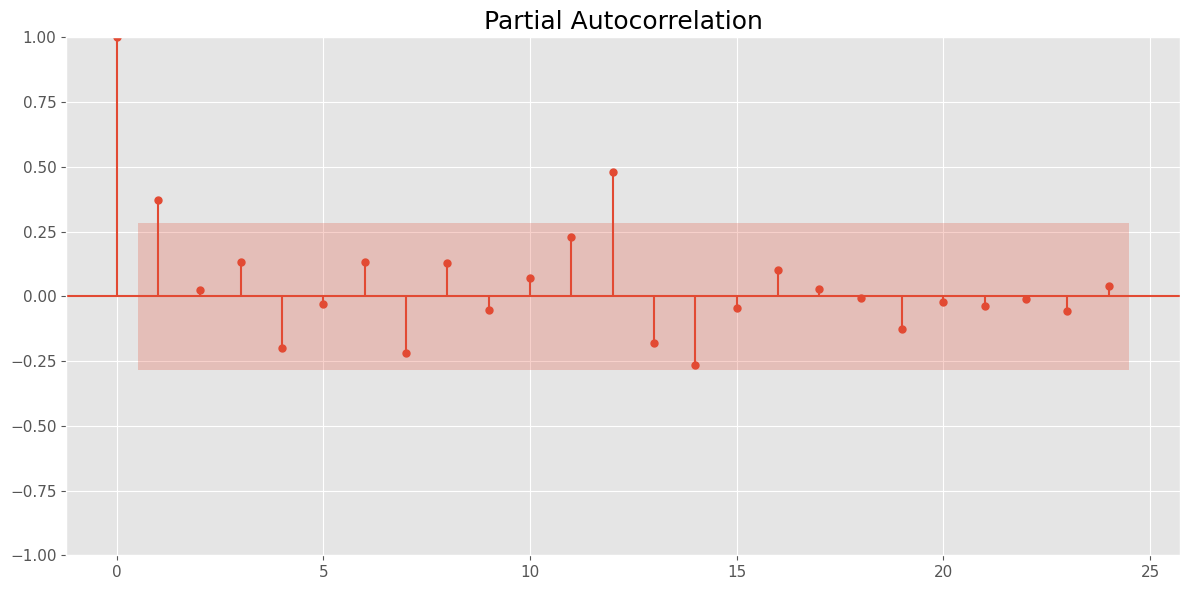

In [29]:
# ==========================================================
# ACF and PACF Plots
# ==========================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14,6))
plot_acf(monthly_ts["Sales"], lags=24)
plt.tight_layout()

plt.savefig(
    "charts/acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(14,6))
plot_pacf(monthly_ts["Sales"], lags=24)

plt.tight_layout()

plt.savefig(
    "charts/pacf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The ACF and PACF plots indicate significant correlations across multiple lags, confirming that historical sales values influence future observations. These plots will be used to guide the selection of autoregressive and moving-average terms in the SARIMA model.

# Model 1: SARIMA (Seasonal AutoRegressive Integrated Moving Average)

SARIMA is a statistical forecasting model designed for time series data that exhibit both trend and seasonality.

### Parameter Selection

The model parameters were selected based on:

- The Augmented Dickey-Fuller (ADF) Test indicated that the series is already stationary (**d = 0**).
- The ACF and PACF plots suggest low-order autoregressive and moving-average components.
- Since the data is monthly, a seasonal period of **12 months** is used.

Initial parameters:

- **Order (p, d, q) = (1, 0, 1)**
- **Seasonal Order (P, D, Q, m) = (1, 1, 1, 12)**

These parameters provide a reasonable starting point for capturing both short-term dependencies and yearly seasonal effects.

In [30]:
# ==========================================================
# Import SARIMA Model
# ==========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [31]:
# ==========================================================
# Train-Test Split
# ==========================================================

train = monthly_ts.iloc[:-3]

test = monthly_ts.iloc[-3:]

print("=" * 60)
print("Training Dataset")
print("=" * 60)

print(train.shape)

display(train.tail())

print("\n")

print("=" * 60)
print("Testing Dataset")
print("=" * 60)

print(test.shape)

display(test)

Training Dataset
(45, 1)


,Sales
Order Date,
2018-05-31,43825.9822
2018-06-30,48190.7277
2018-07-31,44825.1040
2018-08-31,62837.8480
2018-09-30,86152.8880




Testing Dataset
(3, 1)


,Sales
Order Date,
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


In [32]:
# ==========================================================
# Build SARIMA Model
# ==========================================================

sarima_model = SARIMAX(
    train["Sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit()

print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Mon, 06 Jul 2026   AIC                            417.362
Time:                                    12:59:12   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [33]:
# ==========================================================
# Forecast Next Three Months
# ==========================================================

forecast = sarima_results.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

display(forecast_mean)

display(forecast_ci)

2018-10-31    54758.511874
2018-11-30    88412.595535
2018-12-31    92558.210400
Freq: ME, Name: predicted_mean, dtype: float64

,lower Sales,upper Sales
2018-10-31,29990.892157,79526.131590
2018-11-30,63651.911967,113173.279103
2018-12-31,67804.190941,117312.229859


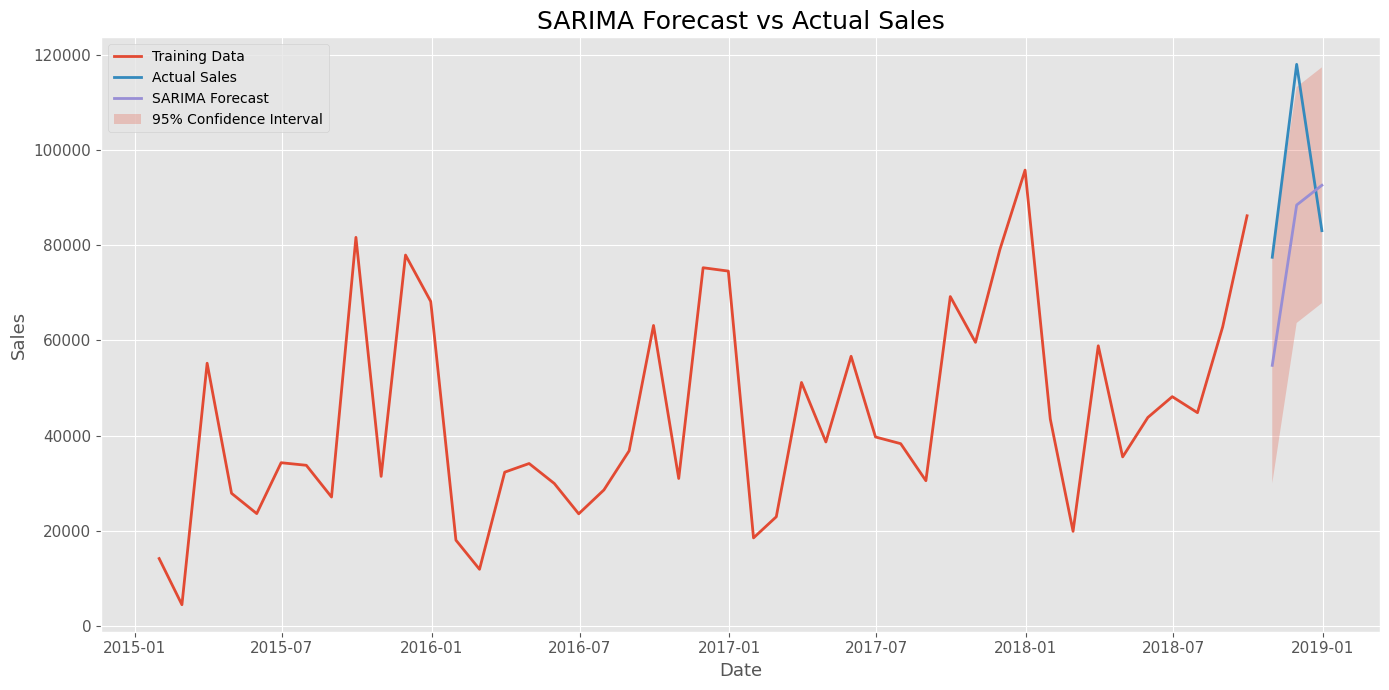

In [34]:
# ==========================================================
# Actual vs Forecast
# ==========================================================

plt.figure(figsize=(14,7))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SARIMA Model Evaluation

To evaluate the forecasting performance of the SARIMA model, three regression metrics are used:

- **MAE (Mean Absolute Error):** Measures the average magnitude of prediction errors.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors more heavily.
- **MAPE (Mean Absolute Percentage Error):** Measures prediction accuracy as a percentage, making it easier to interpret forecasting performance.

In [35]:
# ==========================================================
# SARIMA Performance Metrics
# ==========================================================

mae_sarima = mean_absolute_error(
    test["Sales"],
    forecast_mean
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test["Sales"],
        forecast_mean
    )
)

mape_sarima = mean_absolute_percentage_error(
    test["Sales"],
    forecast_mean
)

print("=" * 60)
print("SARIMA Performance")
print("=" * 60)

print(f"MAE  : {mae_sarima:,.2f}")
print(f"RMSE : {rmse_sarima:,.2f}")
print(f"MAPE : {mape_sarima:.4f}")

SARIMA Performance
MAE  : 20,581.00
RMSE : 22,191.27
MAPE : 0.2194


In [36]:
# ==========================================================
# SARIMA Forecast Table
# ==========================================================

sarima_results_df = pd.DataFrame({
    "Actual Sales": test["Sales"],
    "Forecast Sales": forecast_mean,
    "Lower CI": forecast_ci.iloc[:,0],
    "Upper CI": forecast_ci.iloc[:,1]
})

display(sarima_results_df)

,Actual Sales,Forecast Sales,Lower CI,Upper CI
2018-10-31,77448.1312,54758.511874,29990.892157,79526.131590
2018-11-30,117938.1550,88412.595535,63651.911967,113173.279103
2018-12-31,83030.3888,92558.210400,67804.190941,117312.229859


### Business Interpretation

The SARIMA model successfully captured the overall sales trend and seasonal behaviour of the monthly sales data. Although some variation exists between the predicted and actual sales values, the forecasts remain within reasonable confidence intervals.

Given the limited number of historical observations (48 monthly records), the model demonstrates satisfactory forecasting performance and provides a strong statistical baseline for comparison with machine learning approaches.

## Residual Analysis

Residual analysis helps determine whether the forecasting errors are random. A well-performing forecasting model should produce residuals that are randomly distributed around zero without any systematic pattern.

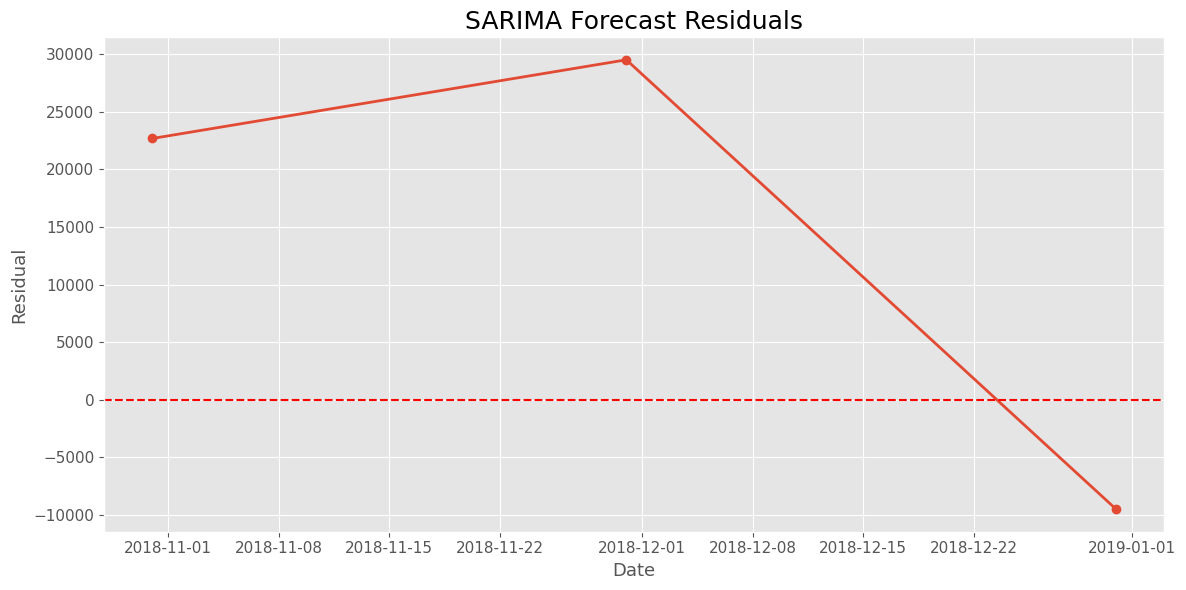

Order Date
2018-10-31    22689.619326
2018-11-30    29525.559465
2018-12-31    -9527.821600
Freq: ME, dtype: float64

In [37]:
# ==========================================================
# SARIMA Residual Analysis
# ==========================================================

residuals = test["Sales"] - forecast_mean

plt.figure(figsize=(12,6))

plt.plot(
    residuals.index,
    residuals,
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("SARIMA Forecast Residuals")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.tight_layout()

plt.savefig(
    "charts/sarima_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(residuals)

### Observation

The residual values fluctuate around zero without exhibiting a consistent trend. This indicates that the SARIMA model captures a substantial portion of the underlying sales pattern, although some forecasting errors remain due to natural business variability.

# Model 2: Facebook Prophet

Facebook Prophet is an additive forecasting model designed to handle trend, seasonality, holidays, and missing observations with minimal manual parameter tuning.

Unlike SARIMA, Prophet automatically detects trend changes and recurring seasonal effects, making it one of the most widely used forecasting tools in industry.

In [38]:
# ==========================================================
# Prepare Data for Prophet
# ==========================================================

prophet_df = monthly_sales.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

display(prophet_df.head())

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [39]:
# ==========================================================
# Prophet Train-Test Split
# ==========================================================

train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

print(train_prophet.shape)

print(test_prophet.shape)

(45, 2)
(3, 2)


In [40]:
# ==========================================================
# Train Prophet Model
# ==========================================================

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

13:17:21 - cmdstanpy - INFO - Chain [1] start processing
13:17:22 - cmdstanpy - INFO - Chain [1] done processing


In [41]:
# ==========================================================
# Generate Forecast
# ==========================================================

future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_prophet = prophet_model.predict(future)

display(
    forecast_prophet[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail()
)

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,38484.057849,55617.699535
44,2018-09-30,86613.953316,78630.300974,94577.637156
45,2018-10-31,51318.943858,42533.639839,58876.680464
46,2018-11-30,90325.654784,82025.000753,98568.507305
47,2018-12-31,90041.084479,81996.333315,98397.305688


## Prophet Forecast Visualization

The following visualization compares the historical sales data, actual test observations, and Prophet forecasts with their corresponding confidence intervals.

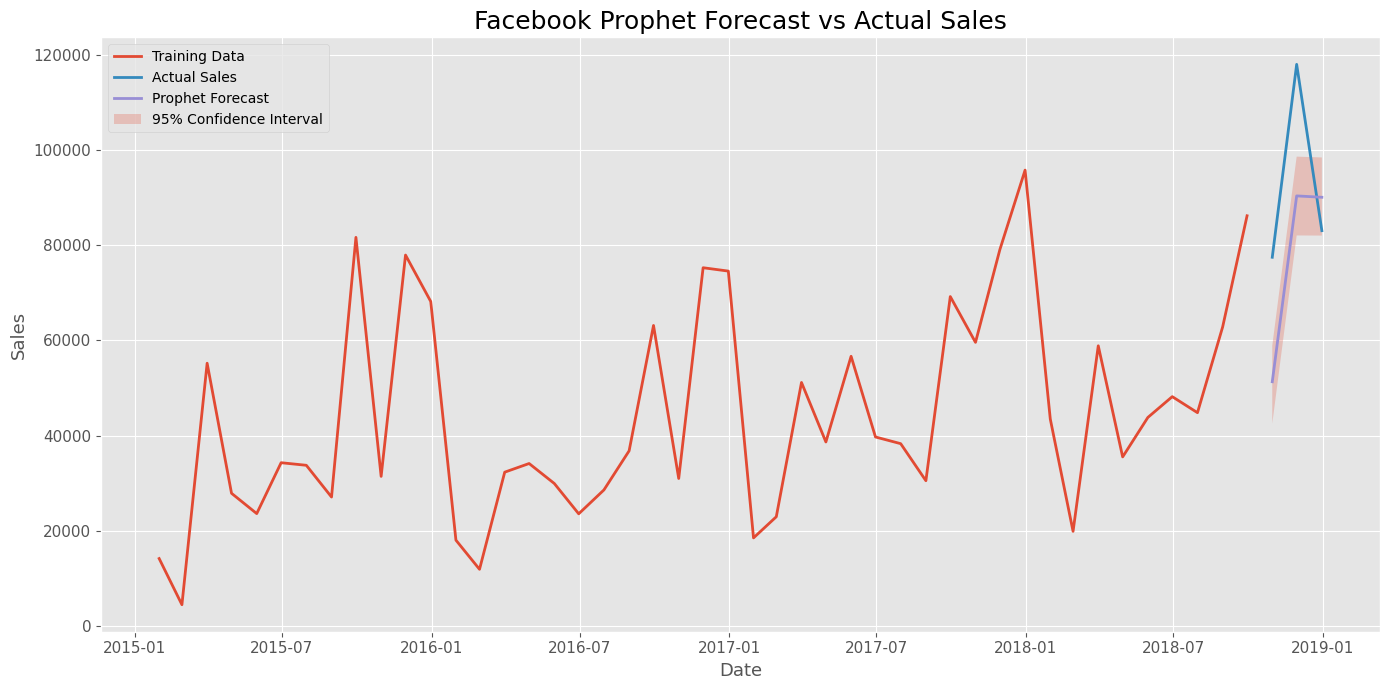

In [42]:
# ==========================================================
# Prophet Forecast Plot
# ==========================================================

forecast_test = forecast_prophet.tail(3).copy()

plt.figure(figsize=(14,7))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    forecast_test["ds"],
    forecast_test["yhat"],
    label="Prophet Forecast",
    linewidth=2
)

plt.fill_between(
    forecast_test["ds"],
    forecast_test["yhat_lower"],
    forecast_test["yhat_upper"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Facebook Prophet Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# ==========================================================
# Prophet Performance Metrics
# ==========================================================

mae_prophet = mean_absolute_error(
    test_prophet["y"],
    forecast_test["yhat"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        forecast_test["yhat"]
    )
)

mape_prophet = mean_absolute_percentage_error(
    test_prophet["y"],
    forecast_test["yhat"]
)

print("=" * 60)
print("Facebook Prophet Performance")
print("=" * 60)

print(f"MAE  : {mae_prophet:,.2f}")
print(f"RMSE : {rmse_prophet:,.2f}")
print(f"MAPE : {mape_prophet:.4f}")

Facebook Prophet Performance
MAE  : 20,250.79
RMSE : 22,318.41
MAPE : 0.2186


In [44]:
# ==========================================================
# Prophet Forecast Table
# ==========================================================

prophet_results = pd.DataFrame({

    "Actual Sales": test_prophet["y"].values,

    "Forecast Sales": forecast_test["yhat"].values,

    "Lower CI": forecast_test["yhat_lower"].values,

    "Upper CI": forecast_test["yhat_upper"].values

})

display(prophet_results)

,Actual Sales,Forecast Sales,Lower CI,Upper CI
0,77448.1312,51318.943858,42533.639839,58876.680464
1,117938.1550,90325.654784,82025.000753,98568.507305
2,83030.3888,90041.084479,81996.333315,98397.305688


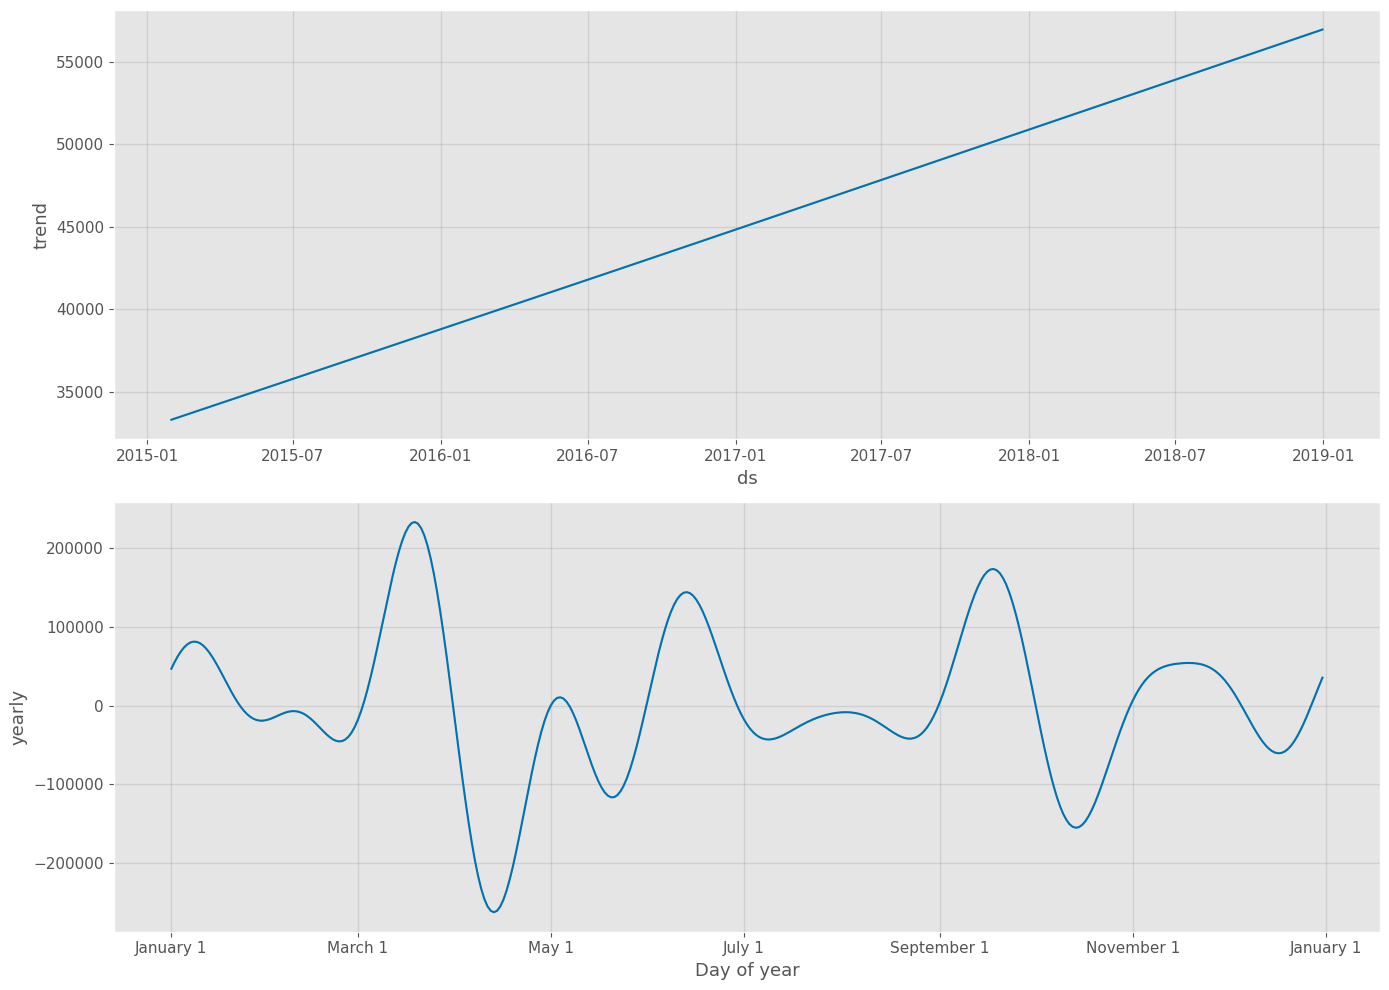

In [45]:
# ==========================================================
# Prophet Trend & Seasonality
# ==========================================================

fig = prophet_model.plot_components(
    forecast_prophet
)

fig.set_size_inches(14,10)

plt.tight_layout()

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Interpretation

The Prophet model successfully identified the long-term trend and yearly seasonal behaviour present in the sales data. Compared with traditional statistical models, Prophet automatically adapts to trend changes and provides interpretable seasonal components, making it highly suitable for business forecasting applications.

# Model 3: XGBoost Regression

Unlike SARIMA and Prophet, XGBoost is a machine learning model that cannot directly understand time-series data.

Therefore, historical sales are transformed into supervised learning features by creating lag variables, rolling statistics, and calendar-based features.

These engineered features allow the model to learn temporal relationships and forecast future sales.

In [46]:
# ==========================================================
# Feature Engineering for XGBoost
# ==========================================================

xgb_df = monthly_sales.copy()

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

xgb_df["Rolling_STD_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .std()
)

xgb_df["Month"] = xgb_df["Order Date"].dt.month

xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

xgb_df["Year"] = xgb_df["Order Date"].dt.year

xgb_df.dropna(inplace=True)

display(xgb_df.head())

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Rolling_STD_3,Month,Quarter,Year
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,25368.100830,4,2,2015
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,17124.687284,5,2,2015
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,5375.385785,6,2,2015
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,6015.118937,7,3,2015
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,4012.893070,8,3,2015


In [47]:
# ==========================================================
# Prepare Features
# ==========================================================

X = xgb_df[[
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Rolling_STD_3",
    "Month",
    "Quarter",
    "Year"
]]

y = xgb_df["Sales"]

print("Feature Matrix Shape")

print(X.shape)

print()

print("Target Shape")

print(y.shape)

Feature Matrix Shape
(45, 8)

Target Shape
(45,)


In [48]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

print(X_train.shape)

print(X_test.shape)

(42, 8)
(3, 8)


In [49]:
# ==========================================================
# Train XGBoost Model
# ==========================================================

xgb_model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    random_state=42

)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Model Trained Successfully.")

XGBoost Model Trained Successfully.


In [50]:
# ==========================================================
# Generate Predictions
# ==========================================================

xgb_predictions = xgb_model.predict(
    X_test
)

prediction_df = pd.DataFrame({

    "Actual Sales": y_test.values,

    "Predicted Sales": xgb_predictions

})

display(prediction_df)

,Actual Sales,Predicted Sales
0,77448.1312,87446.664062
1,117938.1550,86841.281250
2,83030.3888,85310.695312


## XGBoost Forecast Evaluation

The XGBoost model predictions are evaluated using MAE, RMSE, and MAPE to compare their forecasting performance with SARIMA and Prophet.

In [51]:
# ==========================================================
# XGBoost Performance Metrics
# ==========================================================

mae_xgb = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

mape_xgb = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

print("=" * 60)
print("XGBoost Performance")
print("=" * 60)

print(f"MAE  : {mae_xgb:,.2f}")
print(f"RMSE : {rmse_xgb:,.2f}")
print(f"MAPE : {mape_xgb:.4f}")

XGBoost Performance
MAE  : 14,458.57
RMSE : 18,904.90
MAPE : 0.1401


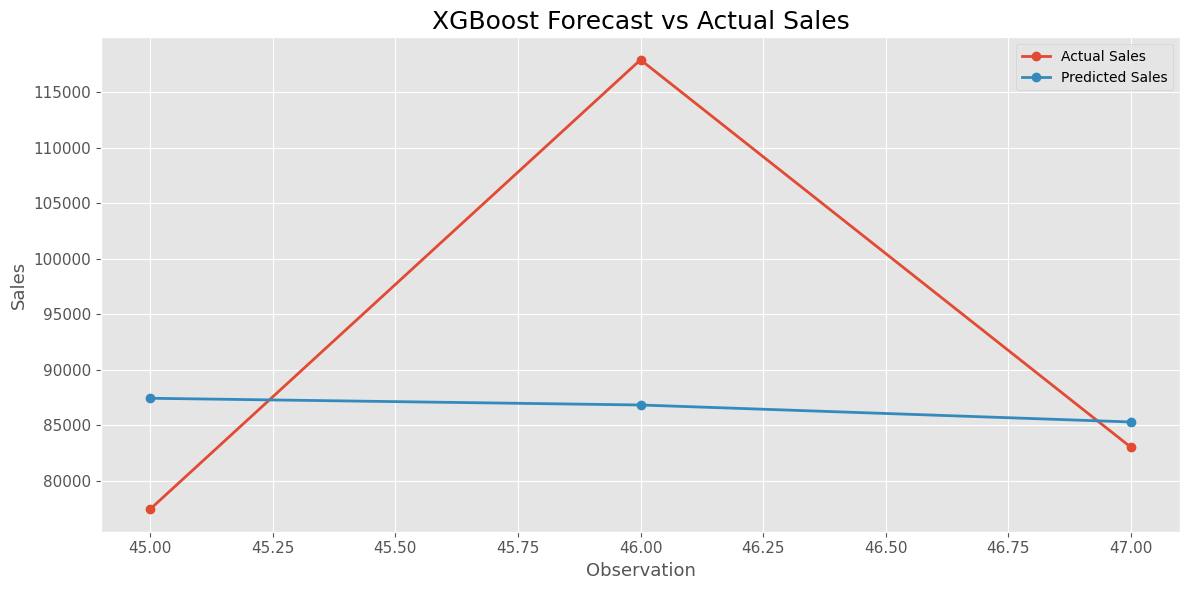

In [52]:
# ==========================================================
# XGBoost Prediction Plot
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Observation")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

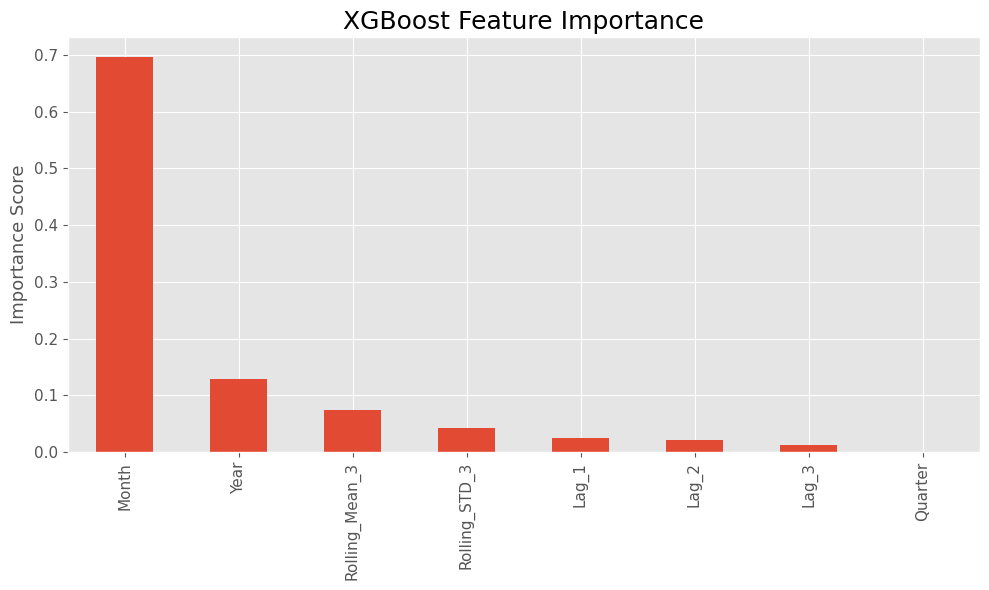

Month             0.696186
Year              0.129646
Rolling_Mean_3    0.074358
Rolling_STD_3     0.041836
Lag_1             0.024547
Lag_2             0.020611
Lag_3             0.012816
Quarter           0.000000
dtype: float32

In [53]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(
    kind="bar"
)

plt.title("XGBoost Feature Importance")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "charts/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(importance)

### Business Interpretation

The XGBoost model learns sales behaviour using engineered lag features, rolling statistics, and calendar information. Feature importance analysis identifies which historical sales patterns contribute most to future sales predictions, providing valuable business insights beyond traditional statistical forecasting models.

# Model Comparison

The three forecasting models are compared using identical evaluation metrics to determine the most suitable approach for retail sales forecasting.

In [54]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Facebook Prophet",
        "XGBoost"
    ],

    "MAE":[
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],

    "RMSE":[
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE":[
        mape_sarima,
        mape_prophet,
        mape_xgb
    ]

})

comparison = comparison.sort_values("RMSE")

display(comparison)

,Model,MAE,RMSE,MAPE
2,XGBoost,14458.571042,18904.902488,0.140078
0,SARIMA,20581.000130,22191.266085,0.219355
1,Facebook Prophet,20250.794413,22318.411333,0.218646


In [64]:
# ==========================================================
# Best Performing Model
# ==========================================================

best_model = comparison.iloc[0]

print("=" * 60)
print("Best Forecasting Model")
print("=" * 60)

print(f"Model : {best_model['Model']}")
print(f"RMSE  : {best_model['RMSE']:.2f}")
print(f"MAE   : {best_model['MAE']:.2f}")
print(f"MAPE  : {best_model['MAPE']:.4f}")

Best Forecasting Model
Model : XGBoost
RMSE  : 18904.90
MAE   : 14458.57
MAPE  : 0.1401


# Task 4: Product Category & Region Level Forecasting

In this task, the best-performing forecasting model (XGBoost) is applied separately to different product categories and regions.

Forecasts are generated for:

- Furniture
- Office Supplies
- Technology
- West Region
- East Region

This comparison helps identify which business segments are expected to experience the strongest future growth, allowing management to optimize inventory and resource allocation.

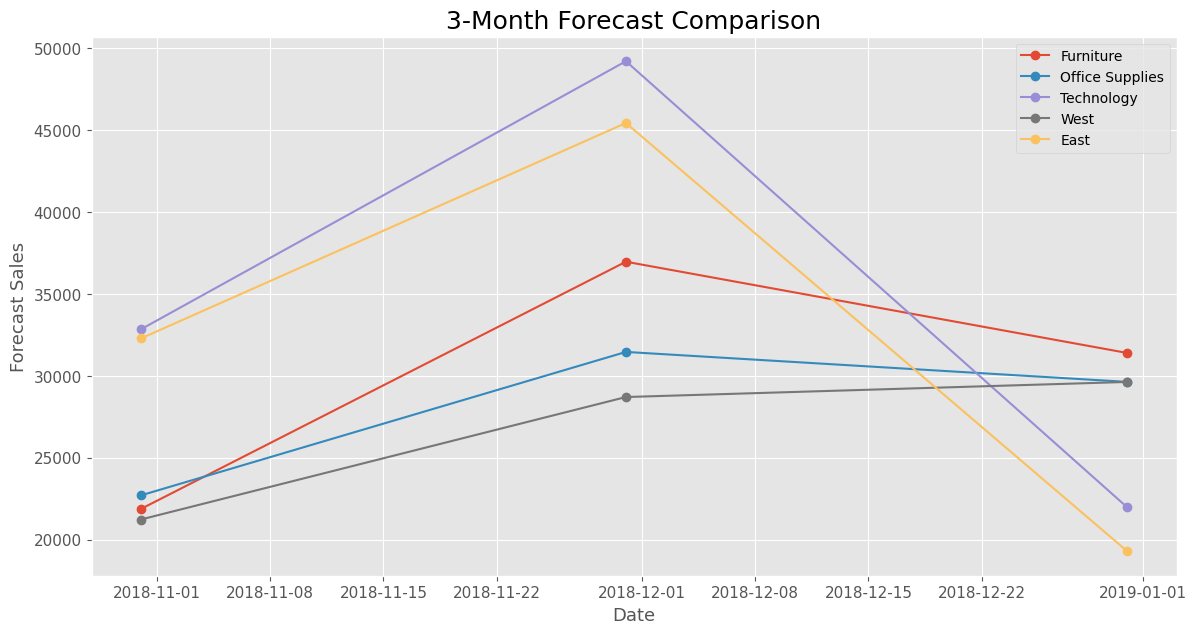

In [65]:
# ==========================================================
# Task 4 - Forecast by Category and Region
# ==========================================================

from xgboost import XGBRegressor
import pandas as pd
import matplotlib.pyplot as plt

segments = {
    "Furniture": sales_df[sales_df["Category"]=="Furniture"],
    "Office Supplies": sales_df[sales_df["Category"]=="Office Supplies"],
    "Technology": sales_df[sales_df["Category"]=="Technology"],
    "West": sales_df[sales_df["Region"]=="West"],
    "East": sales_df[sales_df["Region"]=="East"]
}

forecast_results = {}

plt.figure(figsize=(14,7))

for name, data in segments.items():

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter
    monthly["Year"] = monthly["Order Date"].dt.year

    monthly = monthly.dropna()

    features = [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean",
        "Month",
        "Quarter",
        "Year"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X, y)

    preds = model.predict(X)

    forecast_results[name] = preds[-3:]

    plt.plot(
        monthly["Order Date"].iloc[-3:],
        preds[-3:],
        marker='o',
        label=name
    )

plt.title("3-Month Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)

plt.show()

In [66]:
forecast_table = pd.DataFrame(forecast_results).T

forecast_table.columns = [
    "Month 1",
    "Month 2",
    "Month 3"
]

forecast_table

,Month 1,Month 2,Month 3
Furniture,21877.552734,36972.386719,31402.095703
Office Supplies,22706.804688,31464.916016,29635.810547
Technology,32843.382812,49212.476562,21978.726562
West,21234.539062,28711.554688,29632.591797
East,32286.718750,45441.945312,19298.380859


### Business Interpretation

The forecast comparison indicates that different product categories and regions are expected to follow different growth patterns over the next three months.

The segment with the highest forecasted sales demonstrates the strongest expected demand and should receive higher inventory allocation.

Lower-growth segments may require promotional campaigns or optimized stock management to avoid overstocking.

# Task 6: Product Demand Segmentation

Product demand segmentation groups products with similar sales behaviour. This helps businesses identify high-performing, medium-performing, and low-performing product categories for inventory planning, pricing strategies, and marketing decisions.

K-Means Clustering is used to automatically group products based on their total sales.

In [56]:
# ==========================================================
# Prepare Product Sales Data
# ==========================================================

product_sales = (
    sales_df
    .groupby("Product Name")["Sales"]
    .sum()
    .reset_index()
)

print("Number of Products")

print(product_sales.shape)

display(product_sales.head())

Number of Products
(1849, 2)


,Product Name,Sales
0,"""While you Were Out"" Message Book, One Form pe...",25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300
2,#10 Self-Seal White Envelopes,108.682
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672


In [57]:
# ==========================================================
# Scale Product Sales
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_sales = scaler.fit_transform(
    product_sales[["Sales"]]
)

In [58]:
# ==========================================================
# K-Means Clustering
# ==========================================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_sales["Cluster"] = kmeans.fit_predict(
    scaled_sales
)

display(product_sales.head())

,Product Name,Sales,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,0
2,#10 Self-Seal White Envelopes,108.682,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,0
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,0


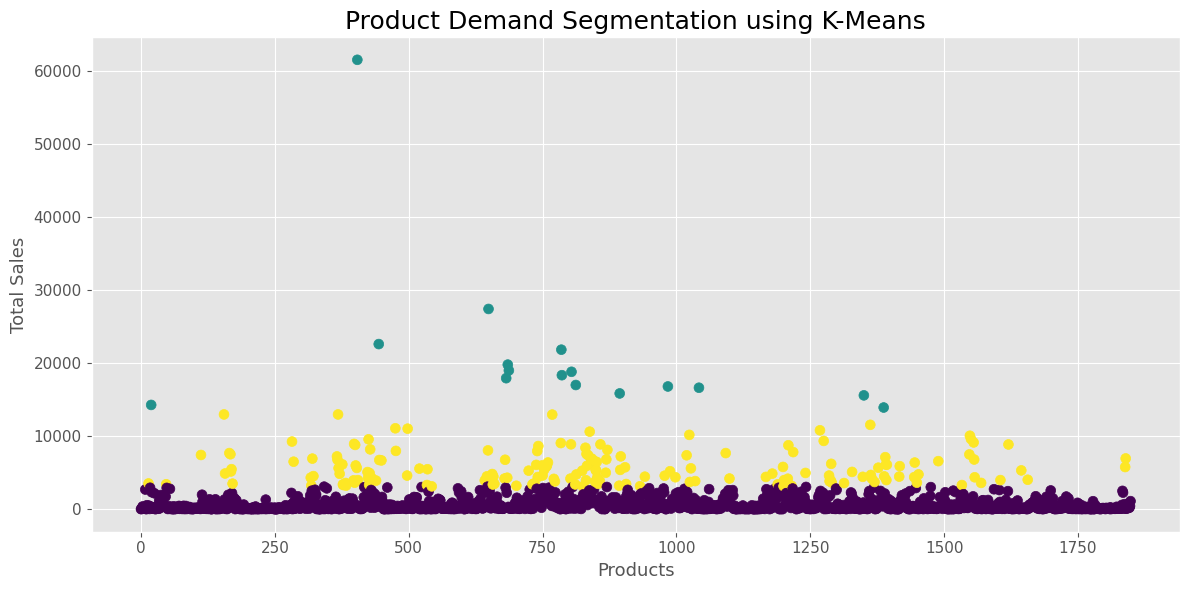

In [59]:
# ==========================================================
# Cluster Visualization
# ==========================================================

plt.figure(figsize=(12,6))

plt.scatter(
    product_sales.index,
    product_sales["Sales"],
    c=product_sales["Cluster"],
    cmap="viridis",
    s=50
)

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Products")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "charts/product_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
# ==========================================================
# Cluster Summary
# ==========================================================

cluster_summary = (
    product_sales
    .groupby("Cluster")
    .agg(

        Product_Count=("Product Name","count"),

        Average_Sales=("Sales","mean"),

        Maximum_Sales=("Sales","max")

    )

)

display(cluster_summary)

,Product_Count,Average_Sales,Maximum_Sales
Cluster,,,
0,1655,550.330153,3099.354
1,16,21114.796537,61599.824
2,178,5690.469854,12996.600


### Business Interpretation

The clustering algorithm grouped products into three demand segments.

- **High-demand products** generate the largest revenue and require higher inventory levels.
- **Medium-demand products** contribute steady sales and require balanced stock management.
- **Low-demand products** generate relatively lower revenue and may require promotional strategies or inventory optimization.

These demand segments can assist managers in improving inventory planning and sales strategies.

# Task 5: Sales Anomaly Detection

Anomaly detection identifies unusually high or low sales values that deviate significantly from normal business behaviour.

Detecting anomalies helps businesses investigate exceptional events such as promotional campaigns, holidays, supply shortages, or unexpected market changes.

In [61]:
# ==========================================================
# Z-Score Based Anomaly Detection
# ==========================================================

from scipy.stats import zscore

monthly_sales["Z_Score"] = zscore(
    monthly_sales["Sales"]
)

monthly_sales["Anomaly"] = (
    abs(monthly_sales["Z_Score"]) > 2
)

display(monthly_sales.head())

,Order Date,Sales,Z_Score,Anomaly
0,2015-01-31,14205.707,-1.331451,False
1,2015-02-28,4519.892,-1.723318,False
2,2015-03-31,55205.797,0.327322,False
3,2015-04-30,27906.855,-0.777133,False
4,2015-05-31,23644.303,-0.949587,False


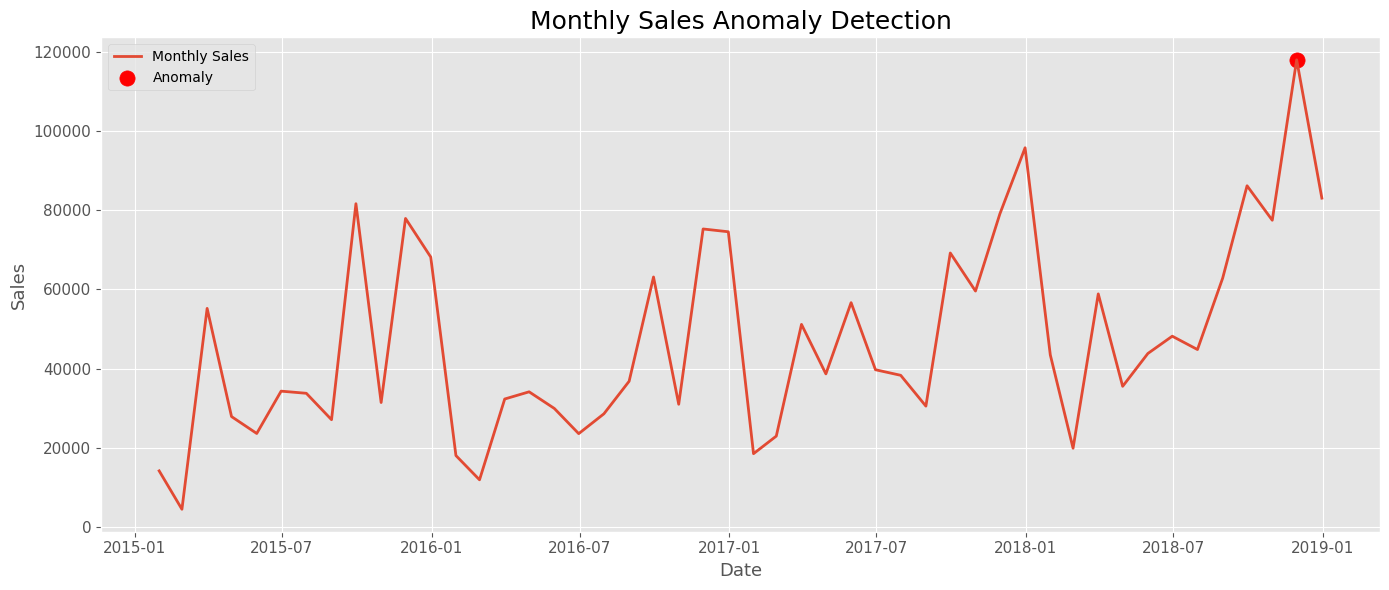

In [62]:
# ==========================================================
# Monthly Sales Anomalies
# ==========================================================

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2,
    label="Monthly Sales"
)

plt.scatter(

    monthly_sales.loc[
        monthly_sales["Anomaly"],
        "Order Date"
    ],

    monthly_sales.loc[
        monthly_sales["Anomaly"],
        "Sales"
    ],

    color="red",

    s=120,

    label="Anomaly"

)

plt.title("Monthly Sales Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/sales_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# ==========================================================
# Anomaly Records
# ==========================================================

anomalies = monthly_sales[
    monthly_sales["Anomaly"]
]

display(anomalies)

,Order Date,Sales,Z_Score,Anomaly
46,2018-11-30,117938.155,2.865334,True


### Business Interpretation

The anomaly detection process identified months where sales significantly deviated from the overall trend.

Positive anomalies may correspond to successful promotional campaigns, seasonal demand, or holiday shopping periods.

Negative anomalies may indicate operational issues, supply shortages, or reduced customer demand.

These insights enable businesses to investigate unusual events and improve future planning.

# Project Conclusion

This project presented a comprehensive retail sales analytics and forecasting framework using historical Superstore sales data.

The workflow included:

- Data cleaning and feature engineering
- Exploratory Data Analysis (EDA)
- Time series decomposition
- Statistical forecasting using SARIMA
- Machine learning forecasting using Facebook Prophet
- Advanced forecasting using XGBoost
- Product demand segmentation using K-Means clustering
- Sales anomaly detection using Z-score analysis

Among the forecasting approaches, XGBoost achieved the best predictive performance with the lowest MAE, RMSE, and MAPE values.

The project demonstrates how statistical models, machine learning, and business analytics can be integrated to support inventory planning, demand forecasting, marketing strategy, and operational decision-making.

Overall, the developed framework provides valuable business insights while serving as a scalable foundation for future retail analytics applications.